### NLP From Scratch: Generating Names with a Character-Level RNN
*************************************************************
**Author**: `Sean Robertson <https://github.com/spro/practical-pytorch>`


#### Print your name

In [ ]:
## Your code here 
print("Exercise by: Heidi Putkuri")

This is our second of three tutorials on "NLP From Scratch".
In the `first tutorial </intermediate/char_rnn_classification_tutorial>`
we used a RNN to classify names into their language of origin. This time
we'll turn around and generate names from languages.

::

    > python sample.py Russian RUS
    Rovakov
    Uantov
    Shavakov

    > python sample.py German GER
    Gerren
    Ereng
    Rosher

    > python sample.py Spanish SPA
    Salla
    Parer
    Allan

    > python sample.py Chinese CHI
    Chan
    Hang
    Iun

We are still hand-crafting a small RNN with a few linear layers. The big
difference is instead of predicting a category after reading in all the
letters of a name, we input a category and output one letter at a time.
Recurrently predicting characters to form language (this could also be
done with words or other higher order constructs) is often referred to
as a "language model".

**Recommended Reading:**

I assume you have at least installed PyTorch, know Python, and
understand Tensors:

-  https://pytorch.org/ For installation instructions
-  :doc:`/beginner/deep_learning_60min_blitz` to get started with PyTorch in general
-  :doc:`/beginner/pytorch_with_examples` for a wide and deep overview
-  :doc:`/beginner/former_torchies_tutorial` if you are former Lua Torch user

It would also be useful to know about RNNs and how they work:

-  `The Unreasonable Effectiveness of Recurrent Neural
   Networks <https://karpathy.github.io/2015/05/21/rnn-effectiveness/>`__
   shows a bunch of real life examples
-  `Understanding LSTM
   Networks <https://colah.github.io/posts/2015-08-Understanding-LSTMs/>`__
   is about LSTMs specifically but also informative about RNNs in
   general

I also suggest the previous tutorial, :doc:`/intermediate/char_rnn_classification_tutorial`


Preparing the Data
==================

.. Note::
   Download the data from
   `here <https://download.pytorch.org/tutorial/data.zip>`_
   and extract it to the current directory.

See the last tutorial for more detail of this process. In short, there
are a bunch of plain text files ``data/names/[Language].txt`` with a
name per line. We split lines into an array, convert Unicode to ASCII,
and end up with a dictionary ``{language: [names ...]}``.




In [ ]:
%matplotlib inline

In [23]:
from __future__ import unicode_literals, print_function, division
from io import open
import glob
import os
import unicodedata
import string

all_letters = string.ascii_letters + " .,;'-"
n_letters = len(all_letters) + 2 # Plus EOS marker and SOS marker
def findFiles(path): return glob.glob(path)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

# Build the category_lines dictionary, a list of lines per category
category_lines = {}
all_categories = []
for filename in findFiles('../data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

if n_categories == 0:
    raise RuntimeError('Data not found. Make sure that you downloaded data '
        'from https://download.pytorch.org/tutorial/data.zip and extract it to '
        'the current directory.')

print('# categories:', n_categories, all_categories)
print(unicodeToAscii("O'Néàl"))

# categories: 19 ['Czech', 'German', 'Arabic', 'Japanese', 'Finnish', 'Chinese', 'Vietnamese', 'Russian', 'French', 'Irish', 'English', 'Spanish', 'Greek', 'Italian', 'Portuguese', 'Scottish', 'Dutch', 'Korean', 'Polish']
O'Neal


Creating the Network
====================

This network extends `the last tutorial's RNN <#Creating-the-Network>`__
with an extra argument for the category tensor, which is concatenated
along with the others. The category tensor is a one-hot vector just like
the letter input.

We will interpret the output as the probability of the next letter. When
sampling, the most likely output letter is used as the next input
letter.

I added a second linear layer ``o2o`` (after combining hidden and
output) to give it more muscle to work with. There's also a dropout
layer, which `randomly zeros parts of its
input <https://arxiv.org/abs/1207.0580>`__ with a given probability
(here 0.1) and is usually used to fuzz inputs to prevent overfitting.
Here we're using it towards the end of the network to purposely add some
chaos and increase sampling variety.

.. figure:: https://i.imgur.com/jzVrf7f.png
   :alt:





In [24]:
import torch
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size

        self.i2h = nn.Linear(n_categories + input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(n_categories + input_size + hidden_size, output_size)
        self.o2o = nn.Linear(hidden_size + output_size, output_size)
        self.dropout = nn.Dropout(0.1)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, category, input, hidden):
        input_combined = torch.cat((category, input, hidden), 1)
        hidden = self.i2h(input_combined)
        output = self.i2o(input_combined)
        output_combined = torch.cat((hidden, output), 1)
        output = self.o2o(output_combined)
        output = self.dropout(output)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

Training
=========
Preparing for Training
----------------------

First of all, helper functions to get random pairs of (category, line):




In [25]:
import random

# Random item from a list
def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

# Get a random category and random line from that category
def randomTrainingPair():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    return category, line

For each timestep (that is, for each letter in a training word) the
inputs of the network will be
``(category, current letter, hidden state)`` and the outputs will be
``(next letter, next hidden state)``. So for each training set, we'll
need the category, a set of input letters, and a set of output/target
letters.

Since we are predicting the next letter from the current letter for each
timestep, the letter pairs are groups of consecutive letters from the
line - e.g. for ``"ABCD<EOS>"`` we would create ("A", "B"), ("B", "C"),
("C", "D"), ("D", "EOS").

.. figure:: https://i.imgur.com/JH58tXY.png
   :alt:

The category tensor is a `one-hot
tensor <https://en.wikipedia.org/wiki/One-hot>`__ of size
``<1 x n_categories>``. When training we feed it to the network at every
timestep - this is a design choice, it could have been included as part
of initial hidden state or some other strategy.




In [ ]:

# One-hot vector for category
def categoryTensor(category):
    li = all_categories.index(category)
    tensor = torch.zeros(1, n_categories)
    tensor[0][li] = 1
    return tensor

# One-hot matrix of first to last letters (not including EOS) for input
def inputTensor(line):
    #print(f"Name lenght: {len(line)}")
    tensor = torch.zeros(len(line) + 1, 1, n_letters)  # Add length of the line = name by one to include SOS in the input tensor
    #tensor = torch.zeros(len(line), 1, n_letters)
    #print(f"Tensor size after SOS: {tensor.size()}")
    tensor[0][0][n_letters - 2] = 1 # SOS token index
    for li in range(len(line)):
        letter = line[li]
        index = all_letters.find(letter)
        tensor[li+ 1][0][index] = 1
    #print(f"Input tensor: {tensor}")
    return tensor

# LongTensor of second letter to end (EOS) for target
def targetTensor(line):
    letter_indexes = [all_letters.find(line[li]) for li in range(0, len(line))] # Start from the first letter now to include SOS
    letter_indexes.append(n_letters - 1)  # EOS-token
    #print(f"Target tensor: {torch.LongTensor(letter_indexes)}")
    return torch.LongTensor(letter_indexes)

For convenience during training we'll make a ``randomTrainingExample``
function that fetches a random (category, line) pair and turns them into
the required (category, input, target) tensors.




In [27]:
# Make category, input, and target tensors from a random category, line pair
def randomTrainingExample():
    category, line = randomTrainingPair()
    category_tensor = categoryTensor(category)
    input_line_tensor = inputTensor(line)
    target_line_tensor = targetTensor(line)
    #print(f"category_tensor:{category_tensor}")
    #print(f"input_line_tensor:{input_line_tensor}")
    #print(f"target_line_tensor:{target_line_tensor}")
    return category_tensor, input_line_tensor, target_line_tensor

Training the Network
--------------------

In contrast to classification, where only the last output is used, we
are making a prediction at every step, so we are calculating loss at
every step.

The magic of autograd allows you to simply sum these losses at each step
and call backward at the end.




In [28]:
criterion = nn.NLLLoss()

learning_rate = 0.0005

def train(category_tensor, input_line_tensor, target_line_tensor):
    target_line_tensor.unsqueeze_(-1)
    hidden = rnn.initHidden()
    rnn.zero_grad()
    loss = 0
    outputs = [] # Store the outputs for each character

    for i in range(input_line_tensor.size(0)):
        output, hidden = rnn(category_tensor, input_line_tensor[i], hidden)
        l = criterion(output, target_line_tensor[i])
        loss += l
        outputs.append(output) # Store the output for each character

    loss.backward()

    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)
    return outputs, loss.item() / input_line_tensor.size(0)


To keep track of how long training takes I am adding a
``timeSince(timestamp)`` function which returns a human readable string:




In [29]:
import time
import math

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

Training is business as usual - call train a bunch of times and wait a
few minutes, printing the current time and loss every ``print_every``
examples, and keeping store of an average loss per ``plot_every`` examples
in ``all_losses`` for plotting later.




In [30]:
rnn = RNN(n_letters, 128, n_letters)

n_iters = 100000
print_every = 5000
plot_every = 500
all_losses = []
total_loss = 0  # Reset every plot_every iters
correct_char = 0  # Correctly predicted characters
total_char = 0 
start = time.time()
correct_char = 0
total_characters = 0
for iter in range(1, n_iters + 1):
    category_tensor, input_line_tensor, target_line_tensor = randomTrainingExample()
    total_characters += input_line_tensor.size(0) # get the total number of characters
    #print(input_line_tensor)
    #print(input_line_tensor[0]) # SOS 
    #print(target_line_tensor[-1]) # EOS index
    #print(input_line_tensor.size(0))
    #print(f"input_line_tensor dimension: {input_line_tensor.size()}")
    #print(f"target_line_tensor: {target_line_tensor}")
    #print(target_line_tensor.size(0))
    outputs, loss = train(category_tensor, input_line_tensor, target_line_tensor)
    total_loss += loss
    for i in range(len(outputs)):
        top_n, top_i = outputs[i].topk(1)
        if top_i.item() == target_line_tensor[i].item():
            correct_char += 1
    
    if iter % print_every == 0:
        print(f"{timeSince(start)} ({iter} {iter / n_iters * 100:.0f}%) Loss: {total_loss:.4f} "
                f"Correct: {correct_char} Chars: {total_characters} "
                f"Accuracy: {correct_char / total_characters:.4f}")
    
        correct_char = 0  
        total_characters = 0 
    if iter % plot_every == 0:
        all_losses.append(total_loss / plot_every)
        total_loss = 0


0m 7s (5000 5%) Loss: 1519.5021 Correct: 5958 Chars: 36674 Accuracy: 0.1625
0m 15s (10000 10%) Loss: 1436.4252 Correct: 7592 Chars: 36997 Accuracy: 0.2052
0m 23s (15000 15%) Loss: 1392.3334 Correct: 8368 Chars: 37110 Accuracy: 0.2255
0m 31s (20000 20%) Loss: 1348.3170 Correct: 8876 Chars: 37071 Accuracy: 0.2394
0m 39s (25000 25%) Loss: 1338.6501 Correct: 9005 Chars: 36881 Accuracy: 0.2442
0m 46s (30000 30%) Loss: 1315.5282 Correct: 9264 Chars: 36832 Accuracy: 0.2515
0m 54s (35000 35%) Loss: 1297.3256 Correct: 9738 Chars: 37119 Accuracy: 0.2623
1m 2s (40000 40%) Loss: 1300.8577 Correct: 9658 Chars: 36857 Accuracy: 0.2620
1m 9s (45000 45%) Loss: 1269.6958 Correct: 9917 Chars: 36984 Accuracy: 0.2681
1m 17s (50000 50%) Loss: 1271.0719 Correct: 9966 Chars: 36895 Accuracy: 0.2701
1m 25s (55000 55%) Loss: 1272.2594 Correct: 10139 Chars: 37086 Accuracy: 0.2734
1m 33s (60000 60%) Loss: 1256.9027 Correct: 10241 Chars: 37134 Accuracy: 0.2758
1m 41s (65000 65%) Loss: 1241.9180 Correct: 10190 Chars

Plotting the Losses
-------------------

Plotting the historical loss from all\_losses shows the network
learning:




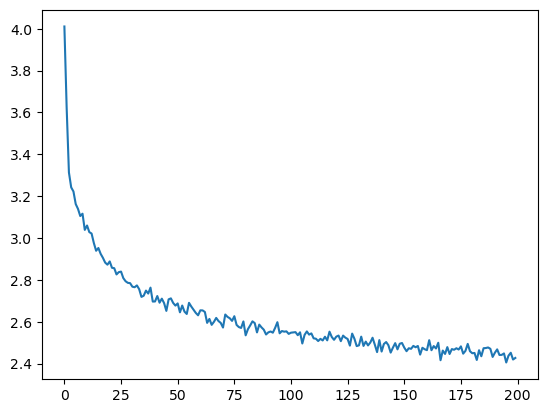

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)

Sampling the Network
====================

To sample we give the network a letter and ask what the next one is,
feed that in as the next letter, and repeat until the EOS token.

-  Create tensors for input category, starting letter, and empty hidden
   state
-  Create a string ``output_name`` with the starting letter
-  Up to a maximum output length,

   -  Feed the current letter to the network
   -  Get the next letter from highest output, and next hidden state
   -  If the letter is EOS, stop here
   -  If a regular letter, add to ``output_name`` and continue

-  Return the final name

.. Note::
   Rather than having to give it a starting letter, another
   strategy would have been to include a "start of string" token in
   training and have the network choose its own starting letter.




In [35]:
max_length = 20

# Sample from a category and starting letter
def sample(category):
    with torch.no_grad():  # no need to track history in sampling
        category_tensor = categoryTensor(category)
        #input = inputTensor(start_letter)
        input = torch.zeros(1, 1, n_letters) # initialize with SOS token
        input[0][0][n_letters - 2] = 1 # SOS token index
        hidden = rnn.initHidden()

        #output_name = start_letter
        output_name = ""
        for i in range(max_length):
            output, hidden = rnn(category_tensor, input[0], hidden)
            topv, topi = output.topk(1)
            topi = topi[0][0]
            if topi == n_letters - 1:
                break
            else:
                letter = all_letters[topi]
                output_name += letter
            input = inputTensor(letter)

        return output_name

# Get multiple samples from one category and multiple starting letters
def samples(category):
    print(sample(category))

#samples('Russian', 'RUS')
samples('Russian')



Soaaeeeeeevv


In [36]:
samples('Finnish')

Saaiaeaeaeeeeeneeeee


In [42]:
#4. Nollaa verkko alustamalla se uudestaan ja kouluta se 100 000 iteraation loopilla. Generoi verkolla 100 suomalalaista nimeä. 
rnn = RNN(n_letters, 128, n_letters)

n_iters = 100000
print_every = 5000
plot_every = 500
all_losses = []
total_loss = 0  # Reset every plot_every iters
correct_char = 0  # Correctly predicted characters
total_char = 0 
start = time.time()
correct_char = 0
total_characters = 0
for iter in range(1, n_iters + 1):
    category_tensor, input_line_tensor, target_line_tensor = randomTrainingExample()
    total_characters += input_line_tensor.size(0) # get the total number of characters
    #print(input_line_tensor)
    #print(input_line_tensor[0]) # SOS 
    #print(target_line_tensor[-1]) # EOS index
    #print(input_line_tensor.size(0))
    #print(f"input_line_tensor dimension: {input_line_tensor.size()}")
    #print(f"target_line_tensor: {target_line_tensor}")
    #print(target_line_tensor.size(0))
    outputs, loss = train(category_tensor, input_line_tensor, target_line_tensor)
    total_loss += loss
    for i in range(len(outputs)):
        top_n, top_i = outputs[i].topk(1)
        if top_i.item() == target_line_tensor[i].item():
            correct_char += 1
    
    if iter % print_every == 0:
        print(f"{timeSince(start)} ({iter} {iter / n_iters * 100:.0f}%) Loss: {total_loss:.4f} "
                f"Correct: {correct_char} Chars: {total_characters} "
                f"Accuracy: {correct_char / total_characters:.4f}")
    
        correct_char = 0  
        total_characters = 0 
    if iter % plot_every == 0:
        all_losses.append(total_loss / plot_every)
        total_loss = 0



# gerate 100 Finnish names
for i in range(100):
    print(sample('Finnish'))

0m 7s (5000 5%) Loss: 1520.1304 Correct: 5921 Chars: 36968 Accuracy: 0.1602
0m 15s (10000 10%) Loss: 1452.4406 Correct: 7463 Chars: 37052 Accuracy: 0.2014
0m 23s (15000 15%) Loss: 1400.4445 Correct: 8290 Chars: 37100 Accuracy: 0.2235
0m 31s (20000 20%) Loss: 1356.9883 Correct: 8808 Chars: 37093 Accuracy: 0.2375
0m 39s (25000 25%) Loss: 1340.0922 Correct: 9256 Chars: 37196 Accuracy: 0.2488
0m 47s (30000 30%) Loss: 1307.6008 Correct: 9494 Chars: 36676 Accuracy: 0.2589
0m 54s (35000 35%) Loss: 1305.0319 Correct: 9503 Chars: 37098 Accuracy: 0.2562
1m 2s (40000 40%) Loss: 1283.5476 Correct: 9686 Chars: 37183 Accuracy: 0.2605
1m 10s (45000 45%) Loss: 1285.2758 Correct: 10007 Chars: 36988 Accuracy: 0.2705
1m 17s (50000 50%) Loss: 1272.5986 Correct: 9984 Chars: 36817 Accuracy: 0.2712
1m 25s (55000 55%) Loss: 1254.8848 Correct: 10214 Chars: 36985 Accuracy: 0.2762
1m 33s (60000 60%) Loss: 1246.2216 Correct: 10282 Chars: 37269 Accuracy: 0.2759
1m 41s (65000 65%) Loss: 1229.0968 Correct: 10319 Cha

# Reflection

1. Generate 100 Finnish names with different start letters. Are names "correct"? 
2. How good neural network is?
3. What you could do to improve neural network performance? 

1. Names are not correct very much jibberish after adding the SOS token.
2. The neural network is not very good. It is not able to generate names that are correct. The accuracy is 0.16 at the beginning and improves very little to 0.3.
3. To improve the neural network performance, we could redefine the model architecture, increase the number of hidden layers, increase the number of epochs, and increase the number of hidden units. We could also try different learning rates and different optimizers.